In [ ]:
### Algoritmo de Búsqueda Codiciosa (Greedy Best-First Search)

In [1]:
import heapq  # Cola de prioridad para extraer siempre el menor h(n)
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
grafo = nx.DiGraph()

In [3]:
grafo.add_weighted_edges_from([
    ("A", "B", 8),
    ("A", "D", 5),
    ("A", "E", 4),
    ("B", "C", 3),
    ("B", "F", 4),
    ("C", "F", 9),
    ("C", "G", 2),
    ("F", "K", 8),
    ("K", "J", 6),
    ("J", "O", 9),
    ("O", "P", 12),
    ("E", "I", 5),
    ("D", "E", 3),
    ("D", "H", 6),
    ("H", "M", 2),
    ("H", "I", 4),
    ("M", "N", 1),
    ("N", "O", 2),
    ("F", "E", 3),
    ("I", "J", 4),
    ("I", "N", 3),
    ("I", "M", 1),
    ("P", "K", 1),
    ("G", "L", 2),
    ("G", "K", 3),
    ("L", "K", 5),
    ("L", "P", 3),
])

In [4]:
# Estimación del costo restante h(n) desde cada nodo hacia la meta 'P'
heuristica = {
    "A": 18,
    "B": 10,
    "C": 7,
    "D": 23,
    "E": 21,
    "F": 24,
    "G": 5,
    "H": 17,
    "I": 16,
    "J": 21,
    "K": 27,
    "L": 3,
    "M": 15,
    "N": 14,
    "O": 12,
    "P": 0,  # La meta siempre tiene h(meta) = 0
}

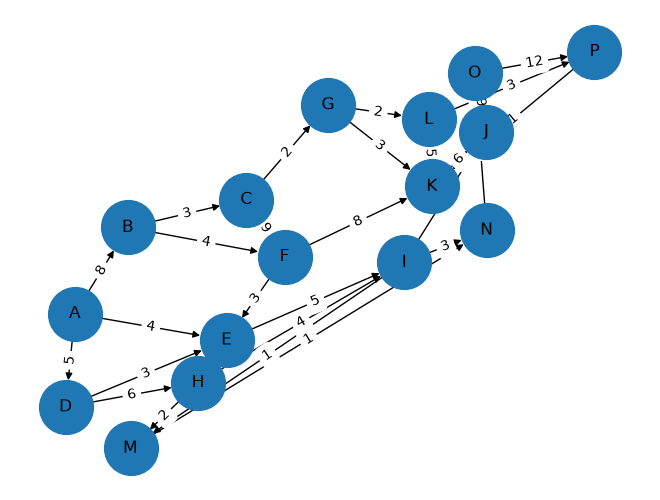

In [6]:
pos = nx.spring_layout(grafo, seed=42)
nx.draw(
    grafo,
    pos,
    with_labels= True,
    node_size=1500,
    arrows=True
)
labels = nx.get_edge_attributes(grafo, "weight")
nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels=labels
)
plt.show()

In [7]:
def busqueda_codiciosa(graph, inicio, objetivo, h):
    # La frontera es una cola de prioridad que almacena: (h_valor, nodo_actual, camino)
    frontera = []
    heapq.heappush(frontera, (h[inicio], inicio, [inicio]))

    visitados = set()

    while frontera:
        # Extrae el nodo con el MENOR valor de h(n) en la frontera
        h_actual, nodo_actual, camino = heapq.heappop(frontera)

        if nodo_actual in visitados:
            continue
        visitados.add(nodo_actual)

        # Si alcanzamos el nodo meta, retornamos el camino
        if nodo_actual == objetivo:
            return camino

        # Explorar vecinos
        for vecino in graph.neighbors(nodo_actual):
            if vecino not in visitados:
                # Se inserta ordenando ÚNICAMENTE por el valor h[vecino]
                heapq.heappush(frontera, (h[vecino], vecino, camino + [vecino]))

    return None

In [8]:
origen = "A"
meta = "P"

camino_encontrado = busqueda_codiciosa(grafo, origen, meta, heuristica)

print(f"Camino encontrado de '{origen}' a '{meta}' usando Búsqueda Codiciosa:")
print(" -> ".join(camino_encontrado))

Camino encontrado de 'A' a 'P' usando Búsqueda Codiciosa:
A -> B -> C -> G -> L -> P


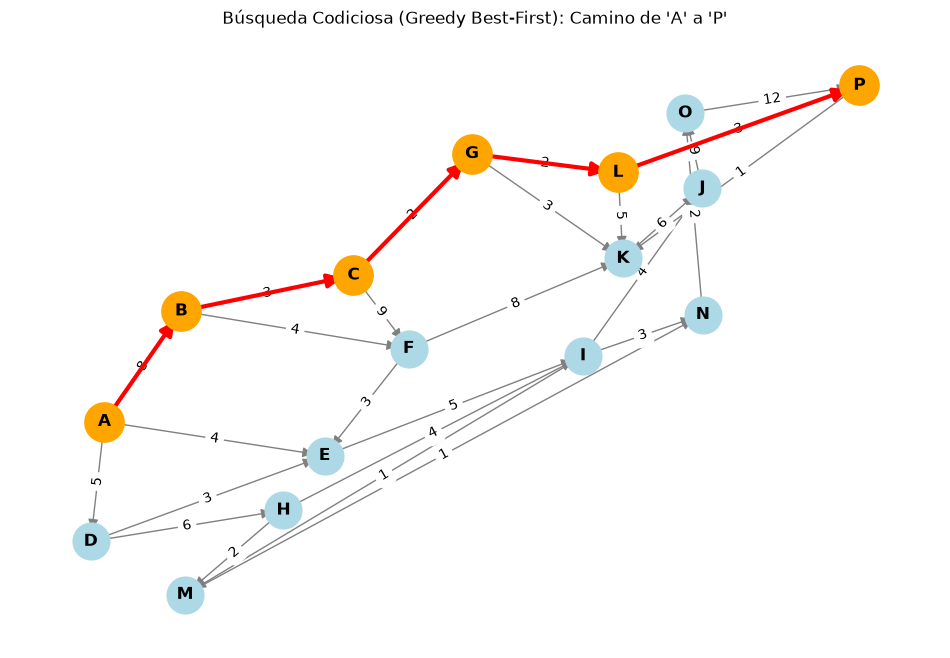

In [9]:
pos = nx.spring_layout(grafo, seed=42)

plt.figure(figsize=(12, 8))

# Dibujar nodos y aristas del grafo
nx.draw_networkx_nodes(grafo, pos, node_color="lightblue", node_size=700)
nx.draw_networkx_labels(grafo, pos, font_size=12, font_weight="bold")
nx.draw_networkx_edges(
    grafo, pos, edge_color="gray", arrows=True, arrowsize=15
)

# Pesos de las aristas
labels_pesos = nx.get_edge_attributes(grafo, "weight")
nx.draw_networkx_edge_labels(grafo, pos, edge_labels=labels_pesos)

# Resaltar en naranja y rojo el camino encontrado
if camino_encontrado:
    aristas_camino = [
        (camino_encontrado[i], camino_encontrado[i + 1])
        for i in range(len(camino_encontrado) - 1)
    ]
    nx.draw_networkx_nodes(
        grafo,
        pos,
        nodelist=camino_encontrado,
        node_color="orange",
        node_size=800,
    )
    nx.draw_networkx_edges(
        grafo,
        pos,
        edgelist=aristas_camino,
        edge_color="red",
        width=3,
        arrows=True,
        arrowsize=20,
    )

plt.title(
    f"Búsqueda Codiciosa (Greedy Best-First): Camino de '{origen}' a '{meta}'"
)
plt.axis("off")
plt.show()